# E-Commerce Customer Analytics
## Bivariate Analysis

This notebook examines pairwise relationships across four e-commerce datasets using correlation analysis, scatterplots, grouped comparisons, pairplots, and time-based trends.

The goal is to identify meaningful associations, potential redundancy, and relationship patterns that can guide later multivariate analysis and predictive modeling.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA_DIR = Path("../data")


## 1. User Behavior & Engagement

This dataset combines customer demographics, order information, sales outcomes, and online engagement behavior. The bivariate analysis focuses on relationships among order value, profitability, engagement actions, and add-to-cart behavior.


### 1.1 Load Data


In [2]:
df_behavior = pd.read_pickle(DATA_DIR / "df_behavior_eda.pkl")
df_behavior.shape


(51207, 27)

### 1.2 Analysis Variables

Numeric variables are used for correlation, scatterplot, and pairplot analysis. Categorical variables are reserved for grouped comparisons, and `Order Date` supports time-based analysis.


In [3]:
numeric_cols_behavior = ["Age", "Sales", "Quantity", "Discount", "Profit","Shipping Cost", "Browsing Time (min)", "Like","Share", "Add to Cart"]

categorical_cols_behavior = ["Segment", "Region", "Gender", "Education","Marital Status", "Ship Mode", "Product Category","Order Priority"]

time_col_behavior = "Order Date"


### 1.3 Correlation Analysis

Pearson correlations are used to screen numeric relationships. Binary engagement variables are included, but their correlations are interpreted as simple associations rather than causal effects.


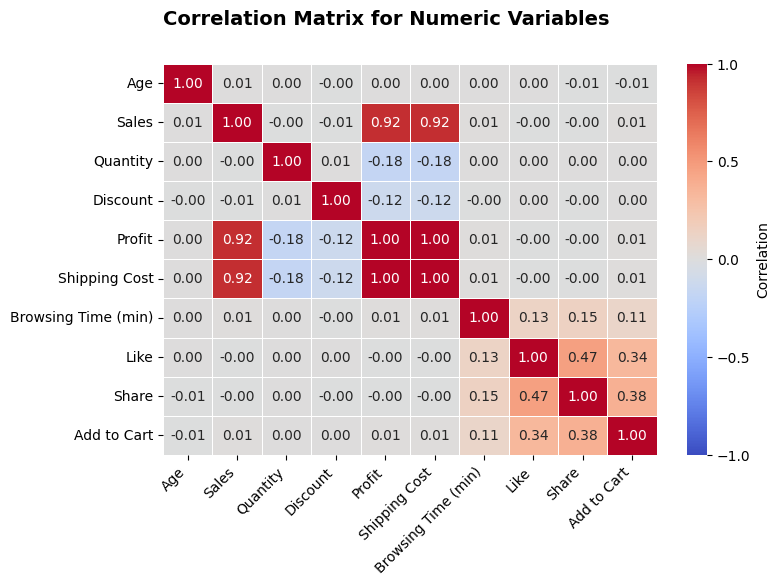

In [4]:
corr_behavior = df_behavior[numeric_cols_behavior].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_behavior,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=14,y=1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The strongest numeric relationships are among `Sales`, `Profit`, and `Shipping Cost`. `Profit` and `Shipping Cost` are especially highly correlated, suggesting substantial overlap in the information they contain.

`Add to Cart` has little linear relationship with the financial variables but shows moderate positive associations with `Like` and `Share`. This suggests that engagement behavior is more closely related to purchase intent than order-value variables in this dataset.


### 1.4 Scatterplots for Key Numeric Relationships

The strongest correlations are examined directly to assess shape, clustering, and possible redundancy.


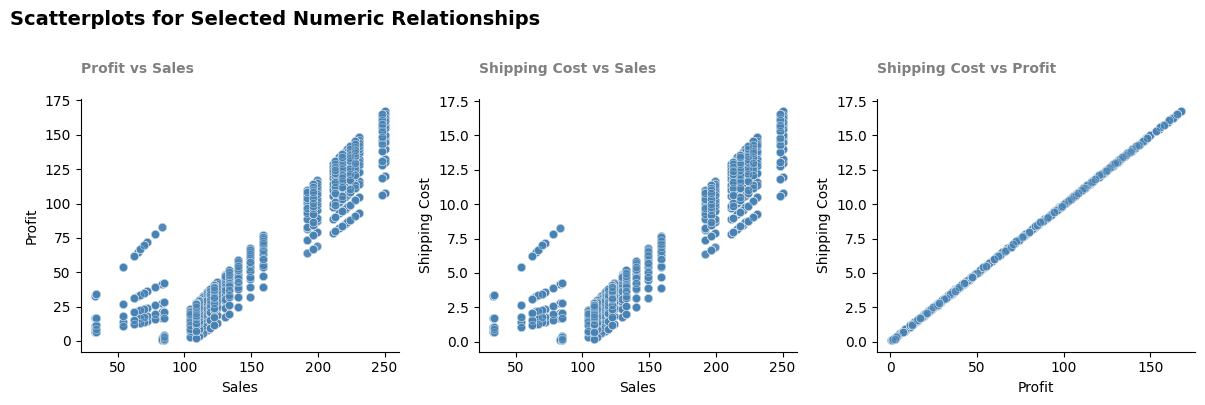

In [5]:
# Scatterplots for important numeric relationships
scatter_pairs_behavior = [("Sales", "Profit"),("Sales", "Shipping Cost"),("Profit", "Shipping Cost")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_behavior):
    sns.scatterplot(data=df_behavior,x=x_col,y=y_col,alpha=0.2,ax=ax[i], color = "steelblue")
    
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, color="gray")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()

The scatterplots confirm strong positive relationships among `Sales`, `Profit`, and `Shipping Cost`. The points form visible groups rather than a single smooth cloud, suggesting that other order characteristics may contribute to the pattern.

`Profit` and `Shipping Cost` are almost perfectly aligned, reinforcing the possibility that they provide overlapping information and should be handled carefully in later modeling.


### 1.5 Add-to-Cart and Engagement Relationships

Because `Add to Cart` is binary, grouped rates provide a clearer comparison than a standard scatterplot.


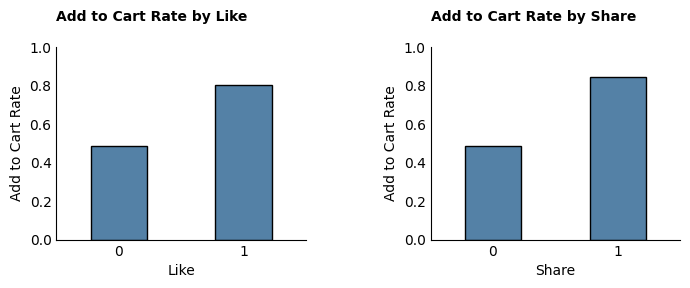

In [6]:
# Add to Cart rate by Like and Share
fig, ax = plt.subplots(1, 2, figsize=(7, 3))

sns.barplot(data=df_behavior,x="Like",y="Add to Cart", estimator="mean", errorbar=None, color="steelblue",width=0.45,ax=ax[0],edgecolor="black")
ax[0].set_title("Add to Cart Rate by Like", loc="left", fontsize=10, fontweight="bold", pad=12, y=1.05)
ax[0].set_xlabel("Like")
ax[0].set_ylabel("Add to Cart Rate")
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis = "x", length=0)
ax[0].tick_params(axis="y", length=0)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

sns.barplot(data=df_behavior,x="Share", y="Add to Cart", estimator="mean",errorbar=None,color="steelblue",width=0.45,ax=ax[1],edgecolor="black")
ax[1].set_title("Add to Cart Rate by Share", loc="left", fontsize=10, fontweight="bold", pad=12, y=1.05)
ax[1].set_xlabel("Share")
ax[1].set_ylabel("Add to Cart Rate")
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis = "x", length=0)
ax[1].tick_params(axis="y", length=0)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
plt.show()

Users who liked or shared an item have higher add-to-cart rates than users who did not. The pattern supports the correlation results and indicates that engagement actions are associated with purchase intent.

These comparisons show association only; they do not establish that liking or sharing causes an item to be added to the cart.


### 1.6 Pairplot of Order-Value Variables

A focused pairplot provides a compact view of the strongest order-value relationships.


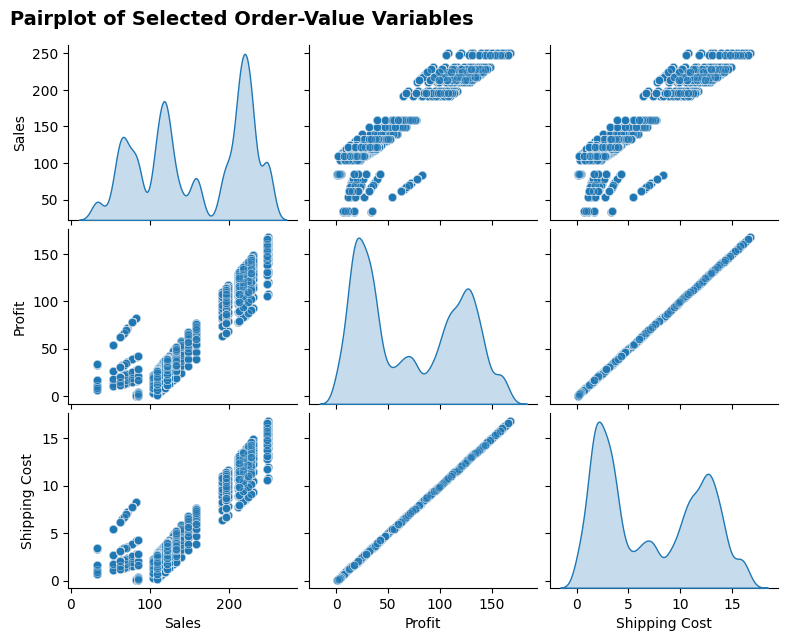

In [7]:
# Pairplot for selected order-value variables
pairplot_cols_behavior = ["Sales","Profit","Shipping Cost"]
g = sns.pairplot(data=df_behavior[pairplot_cols_behavior],diag_kind="kde",plot_kws={"alpha": 0.3})

g.fig.set_size_inches(8, 6)
g.fig.suptitle("Pairplot of Selected Order-Value Variables",fontsize=14, fontweight="bold", y=1.04, x=0.6, ha="right")
plt.show()

The pairplot reinforces the strong relationships among `Sales`, `Profit`, and `Shipping Cost`. The near-linear relationship between `Profit` and `Shipping Cost` is particularly notable, while the grouped structure in the other plots suggests additional variables may influence order value.


### 1.7 Time-Based Analysis

Monthly averages are used to check for obvious trend or drift in sales and add-to-cart behavior.


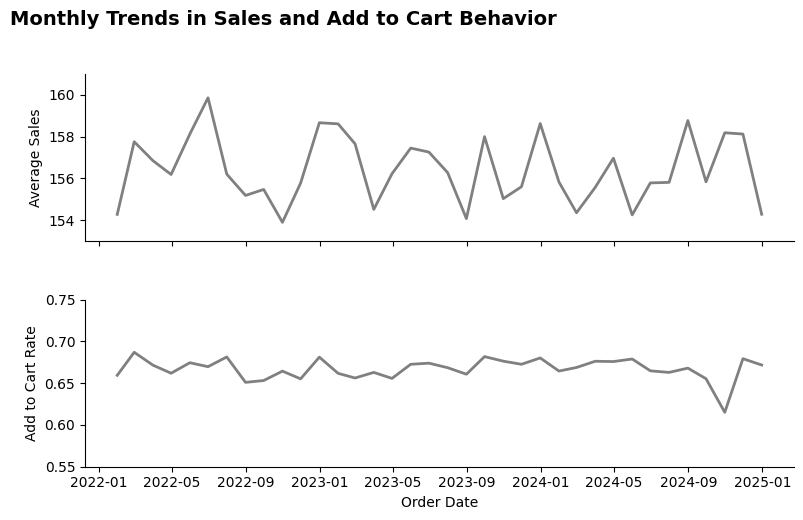

In [8]:
# Monthly trend for Sales and Add to Cart rate

monthly_behavior = (df_behavior.set_index("Order Date").resample("ME").agg({"Sales": "mean","Add to Cart": "mean"}).reset_index())

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

sns.lineplot(data=monthly_behavior,x="Order Date",y="Sales",ax=ax[0],linewidth=2,markersize=5, color = "gray")
ax[0].set_xlabel("")
ax[0].set_ylabel("Average Sales")
ax[0].set_ylim(153, 161)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

sns.lineplot(data=monthly_behavior,x="Order Date",y="Add to Cart",linewidth=2, ax=ax[1],markersize=5, color ="gray")
ax[1].set_xlabel("Order Date")
ax[1].set_ylabel("Add to Cart Rate")
ax[1].set_ylim(0.55, 0.75)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

fig.suptitle("Monthly Trends in Sales and Add to Cart Behavior", fontsize=14, fontweight="bold", y=1.03, x=0, ha="left")

plt.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()

Monthly average sales remains within a relatively narrow range, and the add-to-cart rate is also fairly stable. A short-lived dip appears in add-to-cart behavior, but neither series shows a sustained upward or downward trend.

The y-axes are intentionally focused on the observed ranges, so the visible month-to-month changes are small in absolute terms. Overall, the observed period does not show strong evidence of time-based drift in these two measures.


### 1.8 Sales-Profit Relationship by Product Category

Product category is used to check whether it helps explain the grouped structure visible in the `Sales`–`Profit` relationship.


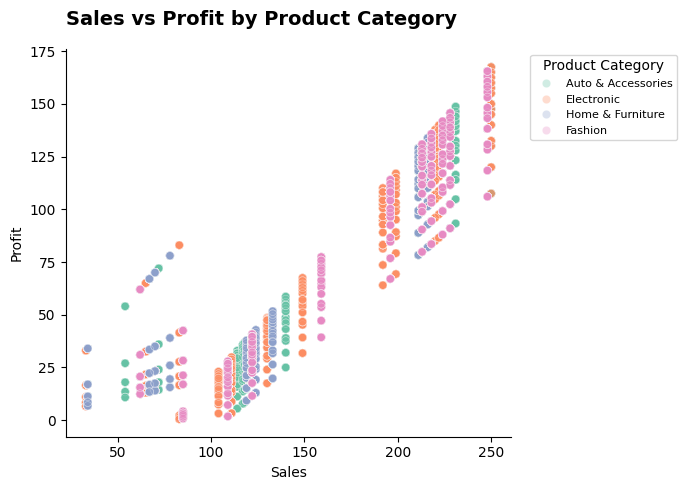

In [9]:
# Sales vs Profit colored by Product Category

plt.figure(figsize=(7, 5))

ax = sns.scatterplot(data=df_behavior,x="Sales",y="Profit",hue="Product Category",alpha=0.3, palette="Set2")

plt.title("Sales vs Profit by Product Category", loc="left", fontsize=14, fontweight="bold", pad=12, y=1.02, x=0, ha="left")
plt.xlabel("Sales")
plt.ylabel("Profit")
ax.legend(title="Product Category", bbox_to_anchor=(1.03, 1), loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Product category explains part of the grouped pattern, with some categories appearing more often in higher-value regions. However, the categories still overlap substantially.

This suggests that category contributes context to the `Sales`–`Profit` relationship but does not explain it by itself.


### 1.9 Dataset 1 Findings

Dataset 1 contains clear bivariate structure. `Sales`, `Profit`, and `Shipping Cost` are strongly related, with `Profit` and `Shipping Cost` showing particularly high overlap. Engagement variables such as `Like` and `Share` are more informative for `Add to Cart` than financial variables.

Monthly sales and add-to-cart behavior are relatively stable, and product category explains only part of the grouped order-value pattern.


## 2. Sales & Customer Insights

This dataset contains customer-value, purchasing, churn-probability, category, region, retention-strategy, and product-timing variables. The analysis evaluates whether these variables show useful pairwise or time-based structure.


### 2.1 Load Data


In [10]:
df_sales = pd.read_pickle(DATA_DIR / "df_sales_eda.pkl")
df_sales.shape


(10000, 15)

### 2.2 Analysis Variables

Numeric variables are used for pairwise analysis, while categorical and date variables are retained for contextual and time-based checks. Identifier columns are excluded from relationship analysis.


In [11]:
numeric_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Churn_Probability","Lifetime_Value"]

categorical_cols_sales = [ "Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy"]

date_cols_sales = ["Launch_Date", "Peak_Sales_Date"]
identifier_cols_sales = ["Customer_ID", "Product_ID", "Transaction_ID"]


### 2.3 Correlation Analysis

Correlations are used to test whether the main customer behavior and value variables move together in a meaningful linear way.


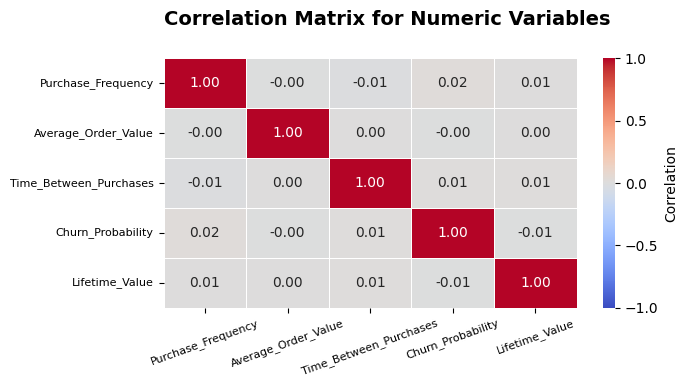

In [12]:
corr_sales = df_sales[numeric_cols_sales].corr()

plt.figure(figsize=(7, 4))
sns.heatmap(corr_sales,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
plt.xticks(rotation=20, fontsize=8)
plt.yticks(fontsize=8)
plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15, y=1.05)
plt.tight_layout()
plt.show()


All selected numeric correlations are close to zero. No strong linear relationships or obvious redundant numeric variables appear in this dataset.

This weak structure is consistent with the earlier observation that the dataset is unusually uniform and provides limited separation across variables.


### 2.4 Scatterplots for Selected Numeric Pairs

Several business-relevant pairs are plotted to confirm whether any non-obvious pattern appears despite the weak correlations.


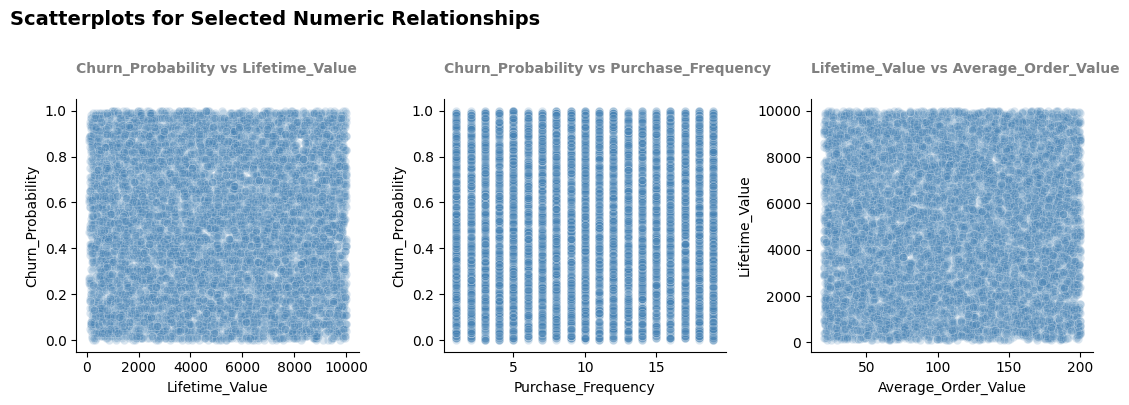

In [13]:
# Scatterplots for selected business-related numeric pairs
scatter_pairs_sales = [("Lifetime_Value", "Churn_Probability"),("Purchase_Frequency", "Churn_Probability"), ("Average_Order_Value", "Lifetime_Value")]

fig, ax = plt.subplots(1, 3, figsize=(11, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_sales):
    sns.scatterplot(data=df_sales,x=x_col, y=y_col,alpha=0.2,ax=ax[i],color="steelblue")
    
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, x=0, color="gray", ha="left")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

The scatterplots confirm the weak correlation results. `Lifetime_Value`, `Churn_Probability`, `Purchase_Frequency`, and `Average_Order_Value` remain broadly dispersed without a clear upward, downward, or clustered pattern.

The vertical bands in `Purchase_Frequency` reflect its discrete count structure rather than a substantive relationship.


### 2.5 Pairplot of Selected Numeric Variables

A pairplot provides a broader check for structure that may not be obvious from individual correlations.


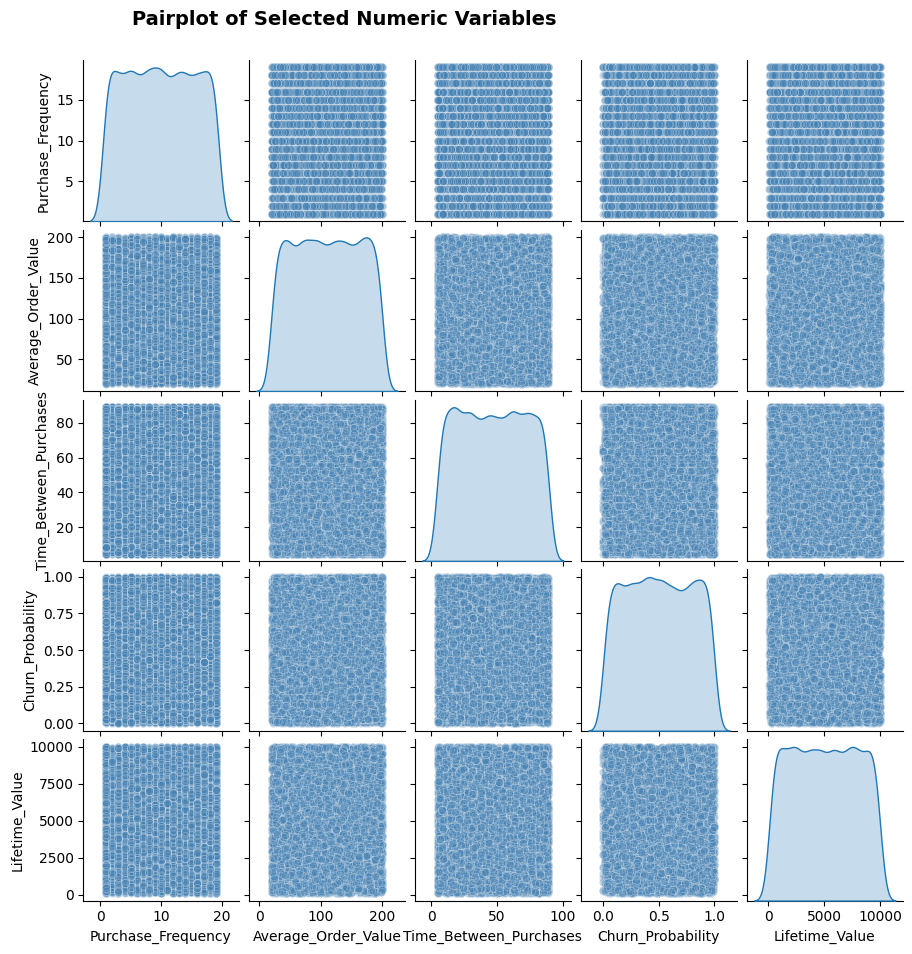

In [14]:
g = sns.pairplot(df_sales[numeric_cols_sales],diag_kind="kde",plot_kws={"alpha": 0.3, "color": "steelblue"})
g.fig.set_size_inches(9, 9)
g.fig.suptitle("Pairplot of Selected Numeric Variables",fontsize=14,fontweight="bold",y=1.04,x=0.6,ha="right")
plt.show()


The pairplot also shows little pairwise structure. The variables are broadly distributed across their ranges, and no useful clustering or directional pattern emerges.


### 2.6 Time-Based Analysis

`Peak_Sales_Date` is used to examine whether average churn probability or lifetime value changes meaningfully over time.


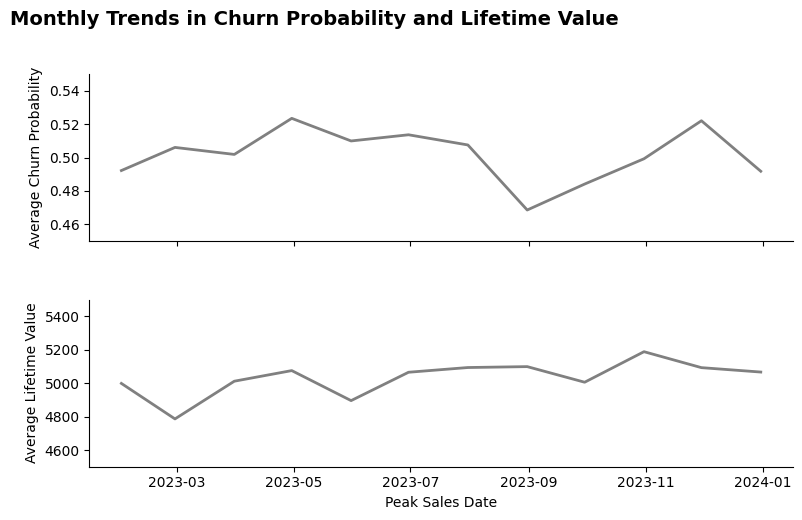

In [15]:
# Monthly trend for churn probability and lifetime value

monthly_sales = (df_sales.set_index("Peak_Sales_Date").resample("ME").agg({"Churn_Probability": "mean","Lifetime_Value": "mean"}).reset_index())

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

sns.lineplot(data=monthly_sales,x="Peak_Sales_Date",y="Churn_Probability",ax=ax[0],linewidth=2,markersize=5,color="gray")
ax[0].set_xlabel("")
ax[0].set_ylabel("Average Churn Probability")
ax[0].set_ylim(0.45, 0.55)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

sns.lineplot(data=monthly_sales,x="Peak_Sales_Date",y="Lifetime_Value",linewidth=2,ax=ax[1],markersize=5,color="gray")
ax[1].set_xlabel("Peak Sales Date")
ax[1].set_ylabel("Average Lifetime Value")
ax[1].set_ylim(4500, 5500)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

fig.suptitle("Monthly Trends in Churn Probability and Lifetime Value",fontsize=14,fontweight="bold",y=1.03, x=0, ha="left")

plt.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()

Average `Churn_Probability` stays close to 0.50, while average `Lifetime_Value` remains near the same general level across months. The axes are focused on the observed ranges, so the visible fluctuations represent relatively small changes.

Because `Peak_Sales_Date` is a product-associated date rather than a longitudinal customer timestamp, this plot is best treated as a descriptive temporal check rather than a customer-level time series.


### 2.7 Dataset 2 Findings

Dataset 2 shows very limited bivariate signal. Numeric correlations are near zero, scatterplots and pairplots do not reveal meaningful structure, and the time-based analysis is largely stable.

The combination of unusually even distributions and weak relationships may indicate a highly simplified, strongly structured, or synthetic-like dataset. For that reason, it provides weaker analytical evidence than the other datasets and should be interpreted cautiously.


## 3. Customer Churn

This customer-level dataset includes tenure, satisfaction, complaints, ordering behavior, cashback, device preference, and churn status. The analysis focuses on pairwise relationships among behavioral variables and on factors associated with churn.


### 3.1 Load Data


In [16]:
df_churn = pd.read_pickle(DATA_DIR / "df_churn_eda.pkl")
df_churn.shape


(5630, 20)

### 3.2 Analysis Variables

Numeric variables are used for correlations and pairwise plots. `Churn` is treated as the target variable, while categorical variables are used for grouped churn-rate comparisons.


In [17]:
numeric_cols_churn = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
    "Churn"
]

categorical_cols_churn = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

identifier_cols_churn = ["CustomerID"]
target_col_churn = "Churn"


### 3.3 Correlation Analysis

The correlation matrix is used to identify stronger numeric relationships and associations with the binary `Churn` target.


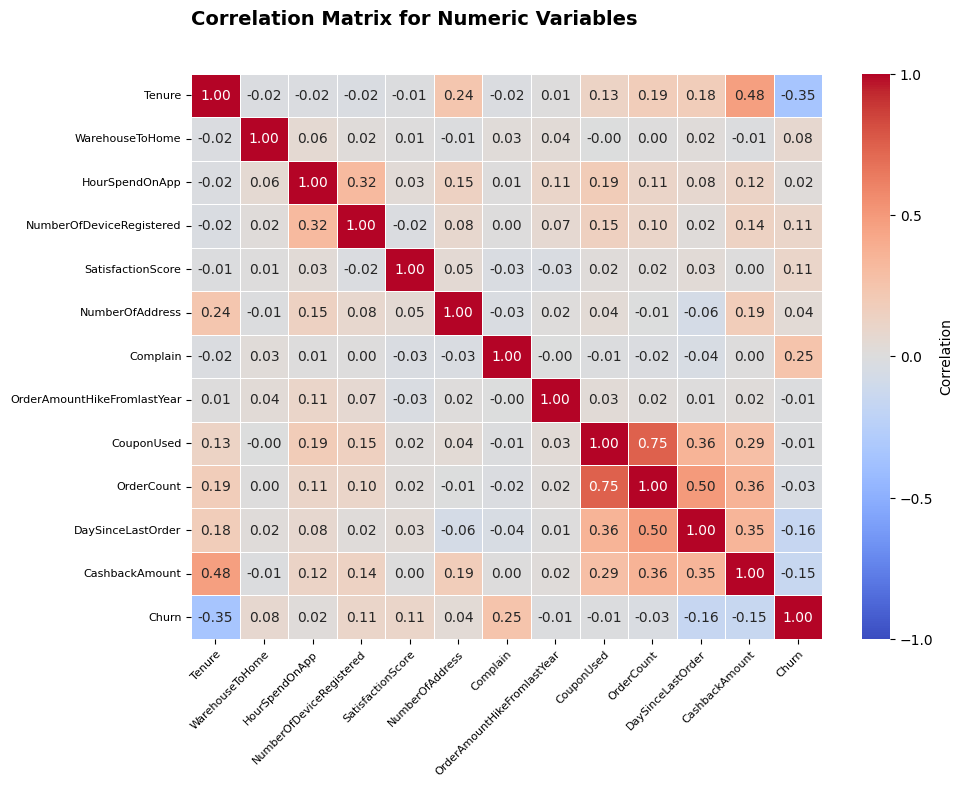

In [18]:
corr_churn = df_churn[numeric_cols_churn].corr()

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr_churn,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=8
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.title(
    "Correlation Matrix for Numeric Variables",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=15,
    y=1.05
)
plt.tight_layout()
plt.show()


Most correlations are weak, but several relationships stand out. `CouponUsed` and `OrderCount` have the strongest positive correlation, while `OrderCount` and `DaySinceLastOrder` and `Tenure` and `CashbackAmount` show moderate positive relationships.

For churn, `Tenure` has the strongest negative association and `Complain` has a notable positive association. These patterns suggest that newer customers and customers who have complained may represent higher-risk groups, although correlation alone does not establish causation.


### 3.4 Scatterplots for Selected Numeric Relationships

The stronger numeric relationships are plotted directly to examine their shape and spread.


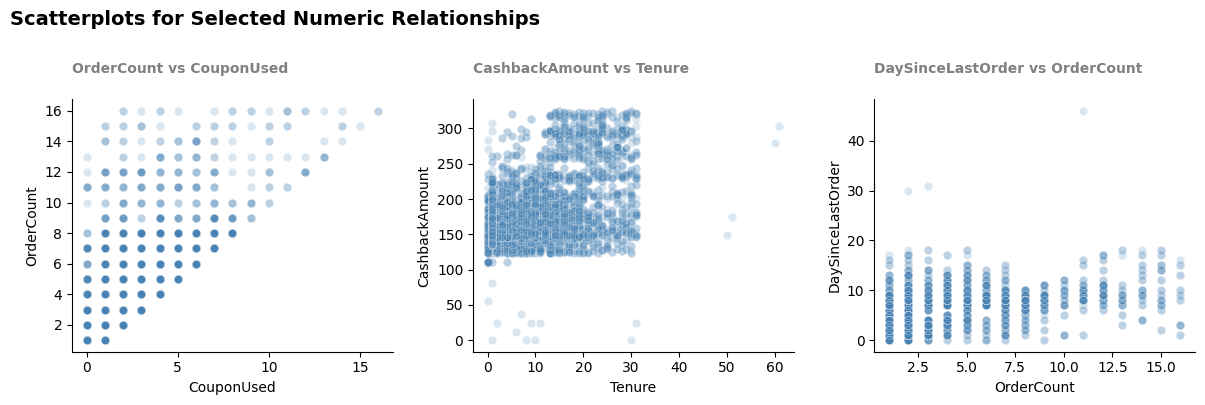

In [19]:
# Scatterplots for selected numeric relationships
scatter_pairs_churn = [("CouponUsed", "OrderCount"),("Tenure", "CashbackAmount"),("OrderCount", "DaySinceLastOrder")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_churn):
    sns.scatterplot(data=df_churn,x=x_col,y=y_col,alpha=0.2,ax=ax[i],color="steelblue")
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, color="gray")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()

`CouponUsed` and `OrderCount` show the clearest positive pattern. `Tenure` and `CashbackAmount` also move together, but with considerably more spread. The relationship between `OrderCount` and `DaySinceLastOrder` is weaker visually.

The grid-like patterns in count variables reflect their discrete nature.


### 3.5 Pairplot of Selected Numeric Variables

A focused pairplot compares selected behavioral variables while separating churned and non-churned customers.


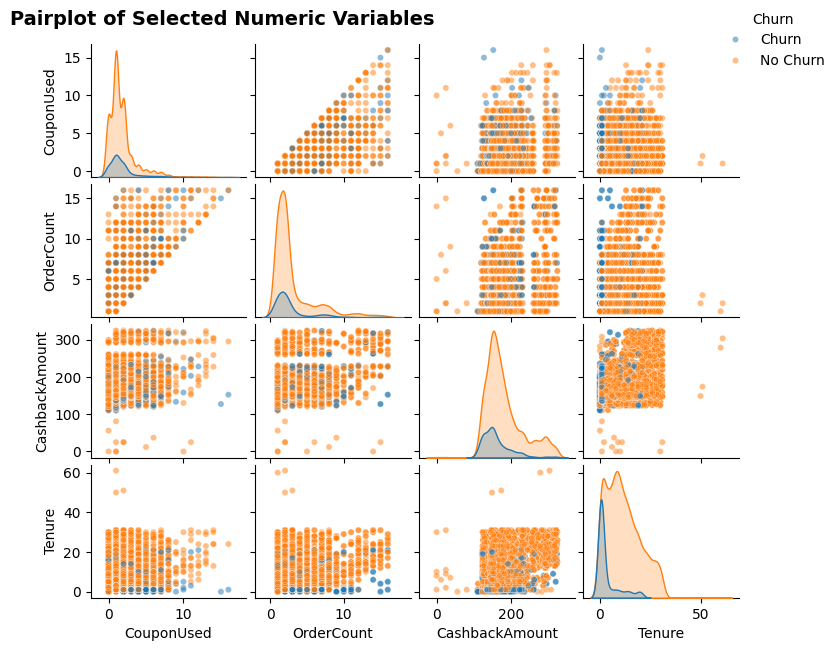

In [20]:
# Pairplot for selected numeric variables
pairplot_cols_churn = ["CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount","Tenure","Churn"]
churn_pairplot = df_churn[pairplot_cols_churn].copy()
churn_pairplot["Churn"] = churn_pairplot["Churn"].map({0: "No Churn",1: "Churn"})

g = sns.pairplot(data=churn_pairplot,vars=["CouponUsed", "OrderCount", "CashbackAmount", "Tenure"], hue="Churn",diag_kind="kde",plot_kws={"alpha": 0.5,"s": 20})

g.fig.set_size_inches(8,6)
g.fig.suptitle("Pairplot of Selected Numeric Variables",fontsize=14, fontweight="bold", y=1.04, x=0.5, ha="right")
g._legend.set_loc("upper right")
plt.show()


The churn groups overlap heavily in most pairwise views. The clearest separation appears in `Tenure`, where churned customers are more concentrated at lower values.

The pairplot also reinforces the strong relationship between `CouponUsed` and `OrderCount`.


### 3.6 Time Variable Availability

This dataset does not contain a true calendar date. `DaySinceLastOrder` measures recency rather than calendar time, so a trend or seasonality plot would not be meaningful.


### 3.7 Churn Relationships Across Customer Groups

Churn rates are compared across complaint status and preferred login device to evaluate whether these groups show meaningful differences.


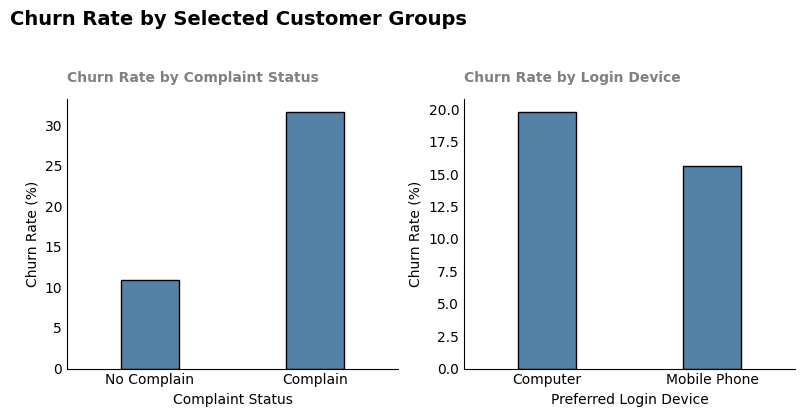

In [21]:
# Churn rate by Complain and Preferred Login Device

complain_churn_rate = df_churn.groupby("Complain")["Churn"].mean().reset_index()
complain_churn_rate["Churn_Rate"] = complain_churn_rate["Churn"] * 100
complain_churn_rate["Complain_Label"] = complain_churn_rate["Complain"].map({0: "No Complain", 1: "Complain"})

login_churn_rate = df_churn.groupby("PreferredLoginDevice")["Churn"].mean().reset_index()
login_churn_rate["Churn_Rate"] = login_churn_rate["Churn"] * 100

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.barplot(data=complain_churn_rate, x="Complain_Label", y="Churn_Rate", width=0.35, color="steelblue", edgecolor="black", ax=axes[0])
axes[0].set_title("Churn Rate by Complaint Status", loc="left", fontsize=10, fontweight="bold", pad=12, color="gray")
axes[0].set_xlabel("Complaint Status")
axes[0].set_ylabel("Churn Rate (%)")

sns.barplot(data=login_churn_rate, x="PreferredLoginDevice", y="Churn_Rate", width=0.35, color="steelblue", edgecolor="black", ax=axes[1])
axes[1].set_title("Churn Rate by Login Device", loc="left", fontsize=10, fontweight="bold", pad=12, color="gray")
axes[1].set_xlabel("Preferred Login Device")
axes[1].set_ylabel("Churn Rate (%)")

for ax in axes:
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Churn Rate by Selected Customer Groups", fontsize=14, fontweight="bold", y=1.03, x=0, ha="left")
plt.tight_layout()
fig.subplots_adjust(wspace=0.2)
plt.show()

Complaint status shows a clear difference in churn rate: customers who complained churn more often than those who did not. Preferred login device also shows some separation, but the difference is smaller.

These are associations within the dataset and should not be interpreted as causal effects.


### 3.8 Dataset 3 Findings

Dataset 3 provides the clearest churn-related bivariate signal among the four datasets. `Tenure` is negatively associated with churn, while `Complain` is positively associated with churn. `CouponUsed` and `OrderCount` also show a strong relationship with each other.

Most variables do not separate churned and non-churned customers strongly on their own, but tenure and complaint status stand out as useful candidates for later multivariate modeling.


## 4. Purchase Experience

This transaction-level dataset contains order value, product, payment, device, browsing, delivery, rating, and returning-customer information. The analysis focuses on order-value relationships, customer experience, and time-based patterns.


### 4.1 Load Data


In [22]:
df_purchase_experience = pd.read_pickle(DATA_DIR / "df_purchase_experience_eda.pkl")
df_purchase_experience.shape


(5000, 18)

### 4.2 Analysis Variables

Numeric variables are used for pairwise analysis, categorical variables for grouped comparisons, and `Date` for monthly trends. Identifier columns are excluded from the main relationship analysis.


In [23]:
numeric_cols_purchase = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount_Amount",
    "Total_Amount",
    "Session_Duration_Minutes",
    "Pages_Viewed",
    "Delivery_Time_Days",
    "Customer_Rating"
]

categorical_cols_purchase = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Device_Type",
    "Is_Returning_Customer"
]

identifier_cols_purchase = ["Order_ID", "Customer_ID"]
date_col_purchase = "Date"


### 4.3 Correlation Analysis

Correlations are used to identify the strongest order-value and customer-experience relationships.


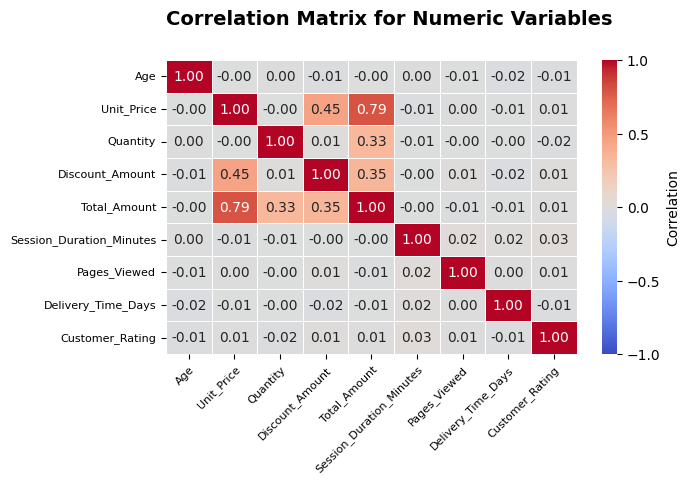

In [24]:
corr_purchase = df_purchase_experience[numeric_cols_purchase].corr()

plt.figure(figsize=(7, 5))
ax = sns.heatmap(
    corr_purchase,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]}
)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor",fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15, y=1.05)
plt.tight_layout()
plt.show()


The strongest relationship is between `Unit_Price` and `Total_Amount`. `Quantity` and `Discount_Amount` also have positive relationships with total order value, while most customer-experience variables show weak linear associations.

`Customer_Rating` has little linear relationship with delivery time, session duration, pages viewed, or order amount in this dataset.


### 4.4 Scatterplots for Key Order-Value Relationships

The strongest and most business-relevant order-value relationships are examined directly.


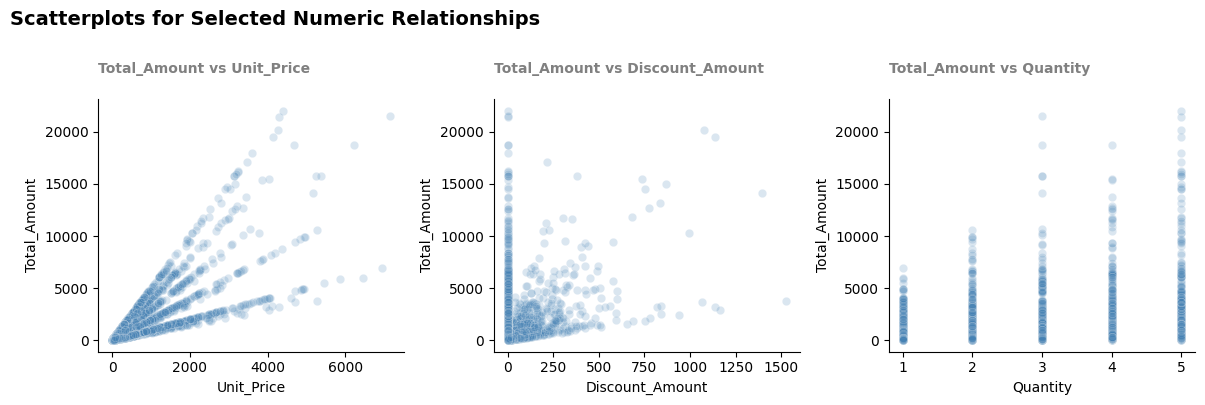

In [25]:
scatter_pairs_purchase = [("Unit_Price", "Total_Amount"),("Discount_Amount", "Total_Amount"),("Quantity", "Total_Amount")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_purchase):
    sns.scatterplot(data=df_purchase_experience,x=x_col, y=y_col,alpha=0.2, ax = ax[i], color="steelblue")
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, color="gray")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.show()

`Unit_Price` has the clearest positive relationship with `Total_Amount`. `Quantity` also contributes to higher total value, producing vertical bands because it takes only a few integer values.

`Discount_Amount` has a weaker positive relationship with total order value, with many transactions concentrated at zero or low discounts.


### 4.5 Pairplot of Order-Value Variables

A focused pairplot summarizes the relationships among price, quantity, discount, and total order value.


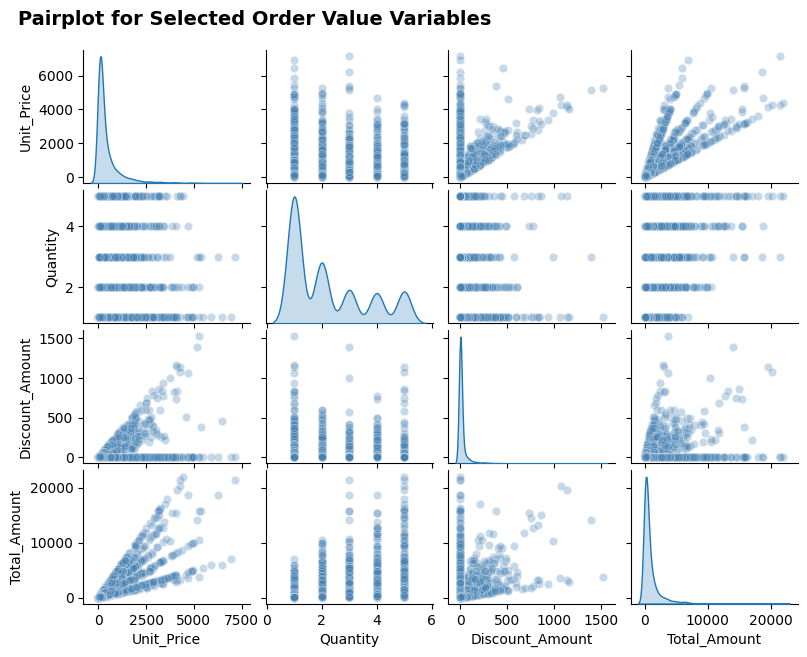

In [26]:
pairplot_cols = ["Unit_Price","Quantity","Discount_Amount","Total_Amount"]

g = sns.pairplot(data=df_purchase_experience[pairplot_cols], diag_kind="kde", plot_kws={"alpha": 0.3, "color": "steelblue"})
g.fig.set_size_inches(8, 6)
g.fig.suptitle("Pairplot for Selected Order Value Variables",fontsize=14, fontweight="bold", y=1.05, x=0.6, ha="right")
plt.show()

The pairplot confirms that the strongest structure is concentrated in the order-value variables. `Unit_Price` and `Total_Amount` are closely related, while `Quantity` produces discrete bands and `Discount_Amount` shows a weaker relationship.

The diagonal distributions also reinforce the strong right-skew in price, discount, and total amount.


### 4.6 Time-Based Analysis

Monthly total sales and average customer rating are used to check whether purchase value or customer satisfaction changes over time.


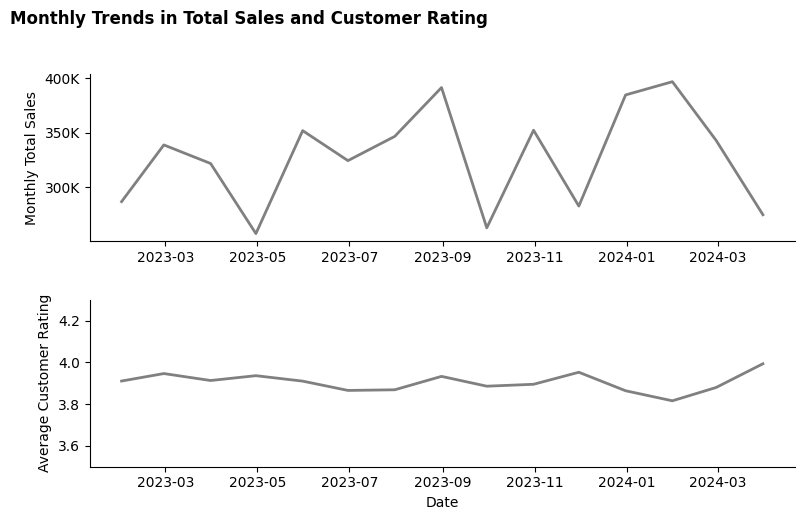

In [27]:
monthly_purchase = (df_purchase_experience.set_index("Date").resample("ME").agg({"Total_Amount": "sum","Customer_Rating": "mean"}).reset_index())

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

sns.lineplot(data=monthly_purchase,x="Date",y="Total_Amount",ax=ax[0],linewidth=2,markersize=5,color="gray")
ax[0].set_xlabel("")
ax[0].set_ylabel("Monthly Total Sales")
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].tick_params(axis="x", labelbottom=True)

sns.lineplot(data=monthly_purchase, x="Date",y="Customer_Rating",ax=ax[1],linewidth=2,markersize=5,color="gray")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Average Customer Rating")
ax[1].set_ylim(3.5, 4.3)

ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].tick_params(axis="x", labelbottom=True)

fig.suptitle("Monthly Trends in Total Sales and Customer Rating",fontsize=12,fontweight="bold",y=1.03,x=0,ha="left")
plt.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()

Monthly total sales varies across the observed period without a clear sustained upward or downward trend. Average customer rating is more stable and remains close to 4.

The rating axis is focused on a narrow observed range, so the visible changes are small in absolute terms. Overall, the plots do not show strong evidence of long-term drift or clear seasonality.


### 4.7 Grouped Relationship Checks

Two grouped comparisons examine whether product category is associated with customer rating and whether returning customers differ in average order value.


#### 4.7.1 Customer Rating by Product Category


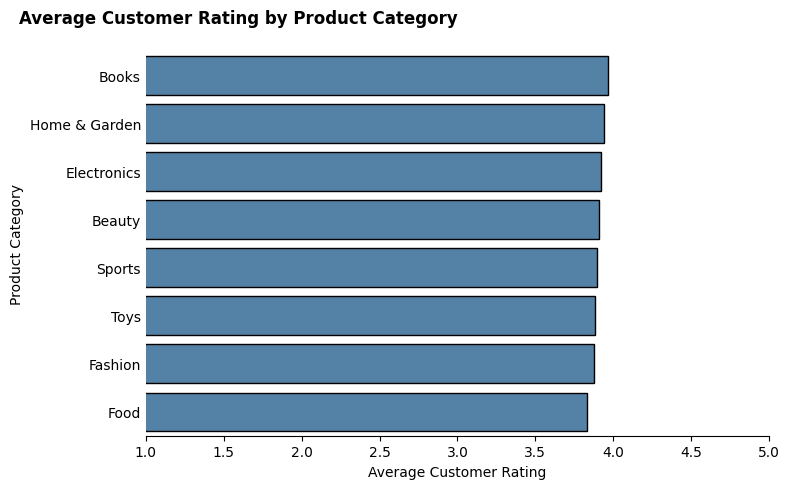

In [28]:
rating_by_category = (df_purchase_experience.groupby("Product_Category")["Customer_Rating"].mean().sort_values(ascending=False).reset_index())

plt.figure(figsize=(8, 5))
g = sns.barplot(data=rating_by_category,x="Customer_Rating",y="Product_Category",color="steelblue",edgecolor="black")

g.set_title("Average Customer Rating by Product Category", loc="left", fontsize=12, fontweight="bold", pad=15, x=0.5, ha="right", y=1.02)
g.set_xlabel("Average Customer Rating")
g.set_ylabel("Product Category")
g.set_xlim(1, 5)
g.tick_params(axis="y", length=0)
g.spines["top"].set_visible(False)
g.spines["right"].set_visible(False)
g.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

Average customer ratings are close across product categories. Small differences are visible, but the categories remain clustered near an average rating of about 4, indicating limited separation in satisfaction.


#### 4.7.2 Total Amount by Returning Customer Status


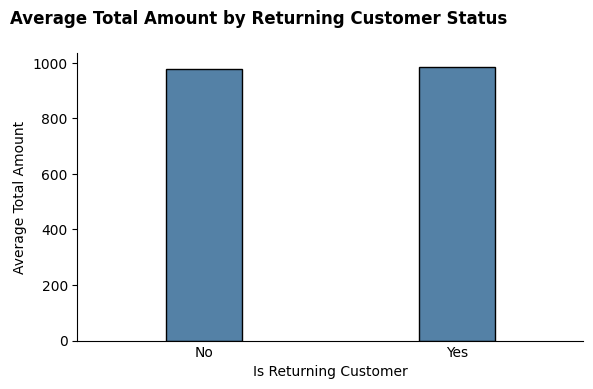

In [29]:
amount_by_returning = (df_purchase_experience.groupby("Is_Returning_Customer")["Total_Amount"].mean().reset_index())
amount_by_returning["Returning_Status"] = amount_by_returning["Is_Returning_Customer"].map({False: "No",True: "Yes"})

plt.figure(figsize=(6, 4))
g = sns.barplot(data=amount_by_returning, x="Returning_Status",y="Total_Amount",color="steelblue",edgecolor="black", width=0.3)

g.tick_params(axis="x", length=0)
g.set_title("Average Total Amount by Returning Customer Status", loc="left", fontsize=12, fontweight="bold", pad=15, y=1.03, x=0.85, ha="right")
g.set_xlabel("Is Returning Customer")
g.set_ylabel("Average Total Amount")
g.spines["top"].set_visible(False)
g.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Average order value is very similar for new and returning customers. Returning customers have a slightly higher average, but the difference is small and does not provide strong separation.


### 4.8 Dataset 4 Findings

Dataset 4 shows meaningful relationships primarily among order-value variables. `Unit_Price` is strongly associated with `Total_Amount`, while `Quantity` and `Discount_Amount` contribute weaker structure.

Customer rating remains relatively stable across product categories and over time, and returning-customer status does not strongly separate average order value.


## Cross-Dataset Takeaways

The four datasets show different levels of bivariate structure:

- **User Behavior & Engagement:** strong relationships among sales, profit, and shipping cost; engagement actions are more closely associated with add-to-cart behavior than financial variables.
- **Sales & Customer Insights:** correlations and pairwise plots show very limited signal, making this dataset weaker for substantive business inference.
- **Customer Churn:** tenure and complaint status stand out as useful churn-related variables, while order count and coupon use show a strong behavioral relationship.
- **Purchase Experience:** the clearest relationships are tied to order value, especially unit price and total amount, while customer rating and returning-customer status show weaker separation.

These findings provide a foundation for the multivariate analysis and predictive modeling stages that follow.
